In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../data/processed/titanic_cleaned.csv")

In [3]:
print("Shape:", df.shape)

Shape: (1309, 19)


In [4]:
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,cabin_missing,survival_rate,average_fare,fare_standardized,age_group
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",0,0.619195,87.508992,3.442584,Young Adult
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",0,0.619195,87.508992,2.286639,Child
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0,0.619195,87.508992,2.286639,Child
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",0,0.619195,87.508992,2.286639,Young Adult
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0,0.619195,87.508992,2.286639,Young Adult


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pclass             1309 non-null   int64  
 1   survived           1309 non-null   int64  
 2   name               1309 non-null   str    
 3   sex                1309 non-null   str    
 4   age                1309 non-null   float64
 5   sibsp              1309 non-null   int64  
 6   parch              1309 non-null   int64  
 7   ticket             1309 non-null   str    
 8   fare               1309 non-null   float64
 9   cabin              295 non-null    str    
 10  embarked           1309 non-null   str    
 11  boat               486 non-null    str    
 12  body               121 non-null    float64
 13  home.dest          745 non-null    str    
 14  cabin_missing      1309 non-null   int64  
 15  survival_rate      1309 non-null   float64
 16  average_fare       1309 non-null   

In [6]:
df[["pclass", "age", "sibsp", "parch", "fare"]].describe()

,pclass,age,sibsp,parch,fare
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000
mean,2.294882,29.503186,0.498854,0.385027,33.281086
std,0.837836,12.905241,1.041658,0.865560,51.741500
min,1.000000,0.170000,0.000000,0.000000,0.000000
25%,2.000000,22.000000,0.000000,0.000000,7.895800
50%,3.000000,28.000000,0.000000,0.000000,14.454200
75%,3.000000,35.000000,1.000000,0.000000,31.275000
max,3.000000,80.000000,8.000000,9.000000,512.329200


In [7]:
df[["pclass", "age", "sibsp", "parch", "fare"]].isnull().sum()

pclass    0
age       0
sibsp     0
parch     0
fare      0
dtype: int64

In [8]:
X = df[["pclass", "age", "sibsp", "parch"]]

In [9]:
y = df["fare"]

In [10]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1309, 4)
Target shape: (1309,)


In [11]:
X.head()

,pclass,age,sibsp,parch
0,1,29.00,0,0
1,1,0.92,1,2
2,1,2.00,1,2
3,1,30.00,1,2
4,1,25.00,1,2


In [12]:
y.head()

0    211.3375
1    151.5500
2    151.5500
3    151.5500
4    151.5500
Name: fare, dtype: float64

In [13]:
print(X.dtypes)
print(y.dtype)

pclass      int64
age       float64
sibsp       int64
parch       int64
dtype: object
float64


In [14]:
from sklearn.model_selection import train_test_split

## Train-Test Split

We split the dataset into training and testing sets so that the models
can learn from one portion of the data and be evaluated on unseen data.

In [15]:
# Split the data into 80% training data and 20% testing data.
# random_state=42 makes the split reproducible.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
# Check the number of rows and columns in each dataset after the split.
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (1047, 4)
Testing features: (262, 4)
Training target: (1047,)
Testing target: (262,)


##  Linear Regression

Linear Regression is used as the first baseline model for predicting passenger
fare. The model learns a linear relationship between passenger class, age,
number of siblings/spouses, and number of parents/children aboard, and the fare.

The model is trained only on the training data and evaluated later on the
unseen testing data.

In [17]:
# Import LinearRegression from Scikit-learn.
# This class provides the Linear Regression machine learning algorithm.
from sklearn.linear_model import LinearRegression

In [18]:
# Create a Linear Regression model.
linear_model = LinearRegression()

In [19]:
# Train the Linear Regression model using only the training data.
# X_train contains the input features and y_train contains the actual fares.
linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[-35.82, -0.02, 6.4 , 10.38]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['pclass','age','sibsp','parch']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,108.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [20]:
# Use the trained model to predict fares for the unseen testing data.
y_pred_linear = linear_model.predict(X_test)

In [21]:
# Compare the first five actual fares with the fares predicted by Linear Regression.
comparison = pd.DataFrame({
    "Actual Fare": y_test.iloc[:5].values,
    "Predicted Fare": y_pred_linear[:5]
})

comparison

,Actual Fare,Predicted Fare
0,7.1250,0.812333
1,15.7417,17.851995
2,7.8958,0.931635
3,8.0500,0.931635
4,7.7500,0.931635


### Evaluating Linear Regression

We evaluate the model using MAE, RMSE, and R². These metrics help us
measure how close the predicted fares are to the actual fares and how well
the model explains variation in passenger fares.

In [22]:
# Import regression metrics from Scikit-learn.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [23]:
# Calculate the Mean Absolute Error.
mae_linear = mean_absolute_error(y_test, y_pred_linear)

# Calculate the Root Mean Squared Error.
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))

# Calculate the R-squared score.
r2_linear = r2_score(y_test, y_pred_linear)

# Print the evaluation results.
print("Linear Regression Results")
print("MAE:", mae_linear)
print("RMSE:", rmse_linear)
print("R²:", r2_linear)

Linear Regression Results
MAE: 21.76792110630464
RMSE: 40.928795634768356
R²: 0.3694351026739987


##  Random Forest Regressor

Random Forest Regressor is the second model used to predict passenger fare.
It combines multiple decision trees and averages their predictions.

Using the same training and testing data as Linear Regression allows us to
make a fair comparison between the two models.

In [24]:
# Import RandomForestRegressor from Scikit-learn.
from sklearn.ensemble import RandomForestRegressor

In [25]:
# Create a Random Forest Regressor.
# n_estimators specifies the number of decision trees in the forest.
# random_state=42 makes the results reproducible.
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [26]:
# Train the Random Forest model using only the training data.
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [27]:
# Predict fares for the unseen testing data.
y_pred_rf = rf_model.predict(X_test)

In [28]:
# Compare the first five actual fares with the Random Forest predictions.
rf_comparison = pd.DataFrame({
    "Actual Fare": y_test.iloc[:5].values,
    "Predicted Fare": y_pred_rf[:5]
})

rf_comparison

,Actual Fare,Predicted Fare
0,7.1250,7.700406
1,15.7417,12.328305
2,7.8958,10.027401
3,8.0500,10.027401
4,7.7500,10.027401


### Evaluating Random Forest

We evaluate the Random Forest model using the same MAE, RMSE, and R² metrics
used for Linear Regression. Using the same metrics allows us to compare the
two models fairly.

In [29]:
# Calculate the Mean Absolute Error for Random Forest.
mae_rf = mean_absolute_error(y_test, y_pred_rf)

# Calculate the Root Mean Squared Error for Random Forest.
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

# Calculate the R-squared score for Random Forest.
r2_rf = r2_score(y_test, y_pred_rf)

# Print the evaluation results.
print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest Results
MAE: 16.33392209981193
RMSE: 43.98395176946958
R²: 0.2717837726748834


## Model Comparison

The two models are compared using MAE, RMSE, and R². Lower MAE and RMSE
indicate smaller prediction errors, while a higher R² indicates that the model
explains more of the variation in passenger fares.

In [30]:
# Create a table comparing the performance of both regression models.
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_linear, mae_rf],
    "RMSE": [rmse_linear, rmse_rf],
    "R²": [r2_linear, r2_rf]
})

model_comparison

,Model,MAE,RMSE,R²
0,Linear Regression,21.767921,40.928796,0.369435
1,Random Forest,16.333922,43.983952,0.271784


##
Linear Regression performed better overall. It achieved a lower RMSE (40.93 compared with 43.98) and a higher R² (0.369 compared with 0.272), indicating that it made fewer large prediction errors and explained more of the variation in passenger fares. Random Forest achieved a lower MAE (16.33 compared with 21.77), meaning its typical absolute prediction error was smaller. Overall, Linear Regression was considered the stronger model because it performed better on RMSE and R², although Random Forest had an advantage in MAE.

##  Visualizing Model Predictions

We compare the actual passenger fares with the fares predicted by each model.
Points closer to the diagonal reference line represent more accurate
predictions.

In [31]:
# Import Matplotlib's pyplot module for creating visualizations.
import matplotlib.pyplot as plt

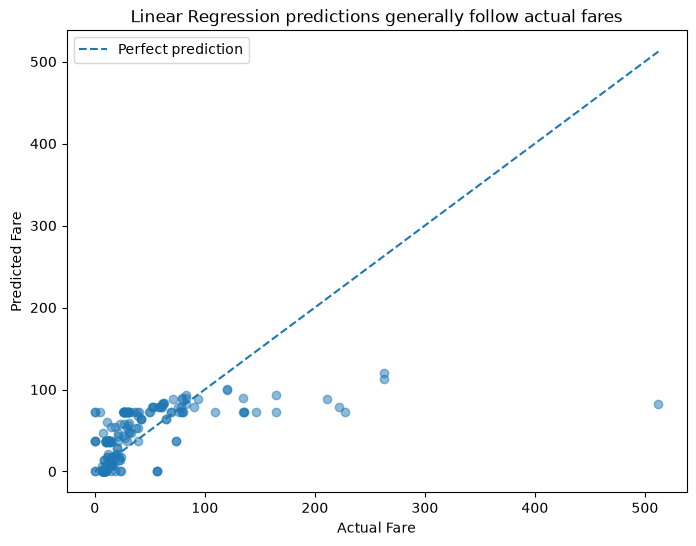

In [32]:
# Create a scatter plot comparing actual fares with Linear Regression predictions.
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_linear, alpha=0.5)

# Create a reference line representing perfect predictions.
min_fare = min(y_test.min(), y_pred_linear.min())
max_fare = max(y_test.max(), y_pred_linear.max())

plt.plot(
    [min_fare, max_fare],
    [min_fare, max_fare],
    linestyle="--",
    label="Perfect prediction"
)

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Linear Regression predictions generally follow actual fares")
plt.legend()

plt.savefig("../reports/a3_linear_regression_predictions.png",
            dpi=150, bbox_inches="tight")

plt.show()

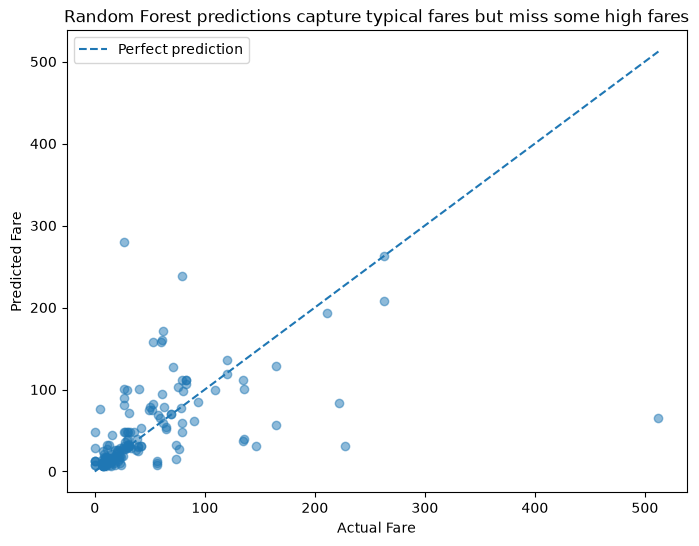

In [33]:
# Create a scatter plot comparing actual fares with Random Forest predictions.
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_rf, alpha=0.5)

# Create the same reference line for perfect predictions.
min_fare = min(y_test.min(), y_pred_rf.min())
max_fare = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [min_fare, max_fare],
    [min_fare, max_fare],
    linestyle="--",
    label="Perfect prediction"
)

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Random Forest predictions capture typical fares but miss some high fares")
plt.legend()

plt.savefig("../reports/a3_random_forest_predictions.png",
            dpi=150, bbox_inches="tight")

plt.show()